# Задание 1

Доля попаданий 95%-го доверительного интервала для отношения дисперсий (25): 0.945
Доля попаданий 95%-го доверительного интервала для отношения дисперсий (10000): 0.968


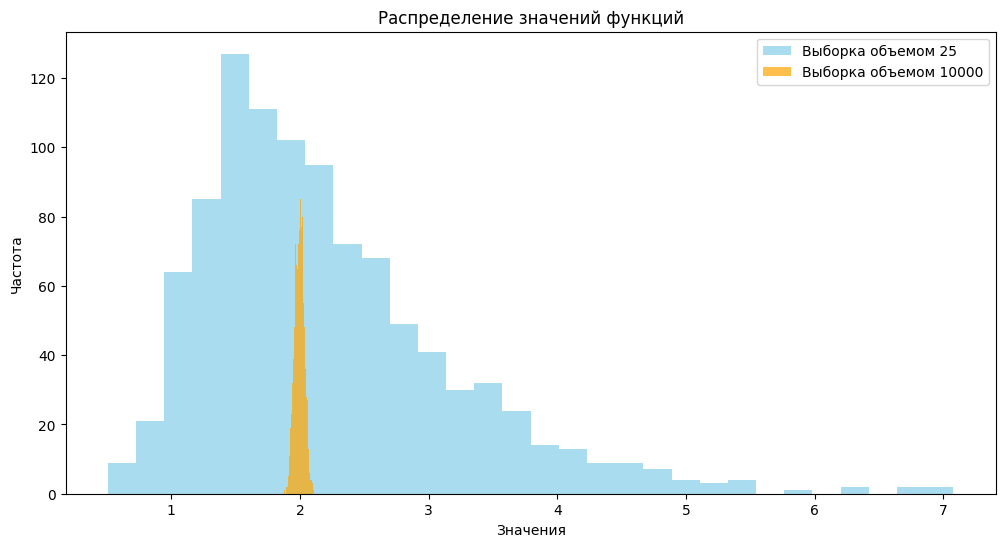

In [21]:
import numpy as np
from scipy.stats import f, norm
import matplotlib.pyplot as plt

def calculate_ratio_of_var(sample1, sample2):
    var1 = np.var(sample1)
    var2 = np.var(sample2)
    return var1 / var2

def confidence_interval(sample1_var, sample2_var, sample_size, result, alpha=0.05):
    f_critical_lower = f.ppf(alpha / 2, sample_size - 1, sample_size - 1)
    f_critical_upper = f.ppf(1 - alpha / 2, sample_size - 1, sample_size - 1)

    ratio = sample1_var / sample2_var

    lower_bound = ratio / f_critical_upper
    upper_bound = ratio / f_critical_lower

    return lower_bound, upper_bound

def experiment(sample_size):
    s = []
    count_covered = 0

    for _ in range(1000):
        mean1 = 0
        mean2 = 0
        std1 = np.sqrt(2)
        std2 = 1

        sample1 = np.random.normal(mean1, std1, sample_size)
        sample2 = np.random.normal(mean2, std2, sample_size)

        result = calculate_ratio_of_var(sample1, sample2)
        s.append(result)

        lower_bound, upper_bound = confidence_interval(std1**2, std2**2, sample_size, result)

        if result >= lower_bound and result <= upper_bound:
            count_covered += 1

    print(f"Доля попаданий 95%-го доверительного интервала для отношения дисперсий ({sample_size}): {count_covered/1000}")

    return s

s = experiment(25)
l = experiment(10000)

# Построение графиков на одной координатной плоскости
plt.figure(figsize=(12, 6))

plt.hist(s, bins=30, color='skyblue', alpha=0.7, label='Выборка объемом 25')
plt.hist(l, bins=30, color='orange', alpha=0.7, label='Выборка объемом 10000')

plt.title('Распределение значений функций')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.legend()

plt.show()

# Задание 2

Доля попаданий 95%-го доверительного интервала для выборок объёма 25: 0.972
Доля попаданий 95%-го доверительного интервала для выборок объёма 10000: 0.983


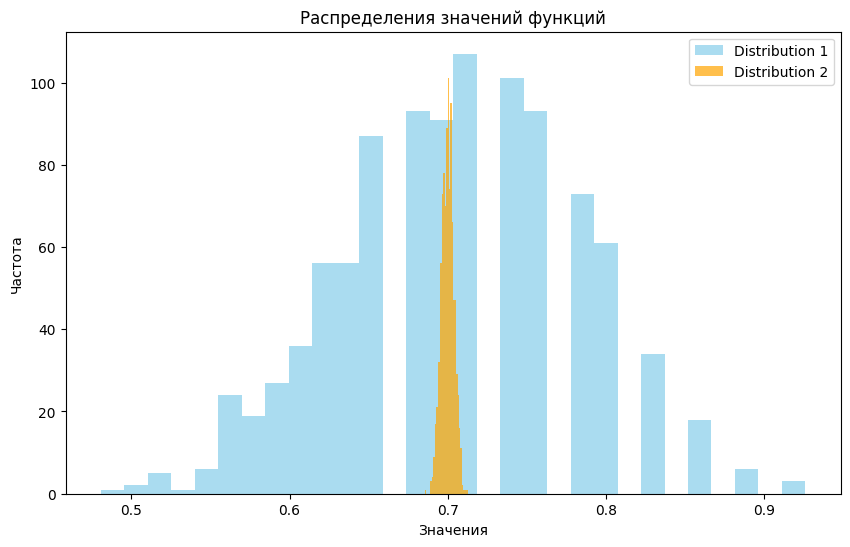

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

import numpy as np
import scipy.stats as stats

#Расчёт доверительного интервала
def confidence_interval_geom(data, p_hat, alpha=0.05):
    n = len(data)

    z = stats.norm.ppf(1 - alpha / 2)  # Z-значение для доверительного интервала

    lower_bound = p_hat - z * np.sqrt( p_hat*(1- p_hat)/n)
    upper_bound = p_hat + z * np.sqrt( p_hat*(1- p_hat)/n)

    return lower_bound, upper_bound

# Оцениваемый параметр
p = 0.7
s = []
l = []

def exp(v, m):
    count_covered = 0
    for _ in range(1000):

        data = np.random.geometric(0.7, v)  # Генерация выборки геометрического распределения с вероятностью 0.7
        p_hat = 1 / np.mean(data)
        lower, upper = confidence_interval_geom(data, p_hat)

        m.append(p_hat)

        # Проверка попадания реального значения параметра в доверительный интервал
        if p >= lower and p <= upper:
            count_covered += 1

    # Вывод результата
    print(f"Доля попаданий 95%-го доверительного интервала для выборок объёма {v}: {count_covered / 1000}")

#Проведение экспериментов
exp(25, s)
exp(10000, l)

#Построение графика
plt.figure(figsize=(10, 6))
plt.hist(s, bins=30, alpha=0.7, color='skyblue', label='Distribution 1')
plt.hist(l, bins=30, alpha=0.7, color='orange', label='Distribution 2')
plt.title('Распределения значений функций')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.legend()
plt.show()